In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.max_columns', None)
import time
import datetime as dt
import gc

from IPython.display import display, HTML
display(HTML("<style>.container { width:85% !important; }</style>"))




from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from feature_engine.selection import DropConstantFeatures,SmartCorrelatedSelection




In [2]:
df = pd.read_parquet("result/facts/all_facts.parquet")
df

,account_id,overall_cnt_credit,overall_cnt_debit,overall_cnt_services,overall_amt_credit,overall_amt_debit,overall_amt_services,recency_credit,recency_debit,recency_services,account_age,txn_cnt_3_credit,txn_cnt_3_debit,txn_cnt_3_services,txn_cnt_2_credit,txn_cnt_2_debit,txn_cnt_2_services,txn_amt_3_credit,txn_amt_3_debit,txn_amt_3_services,txn_amt_2_credit,txn_amt_2_debit,txn_amt_2_services,second_last,last,is_churn
0,1000000,1,7,0,128.900,1990.160,0.000,160,243,-1,648,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0
1,1000001,4,3,1,2094.690,1181.730,870.820,486,338,403,688,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0
2,1000002,3,3,2,2184.480,1357.240,1282.570,147,76,310,613,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0
3,1000003,2,4,3,965.010,1861.110,1387.660,209,6,23,493,0,0,0,0,1,1,0.000,0.000,0.000,0.000,233.940,843.250,0,6,1
4,1000004,2,4,0,1412.470,1016.070,0.000,86,88,-1,486,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999929,1999995,7,1,2,3202.840,631.760,1350.680,44,72,371,609,1,0,0,0,0,0,74.040,0.000,0.000,0.000,0.000,0.000,1,0,1
999930,1999996,4,5,2,1748.080,2244.330,978.720,29,358,219,630,0,0,0,1,0,0,0.000,0.000,0.000,625.190,0.000,0.000,0,1,1
999931,1999997,1,6,1,933.600,2117.650,778.140,410,82,172,578,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0
999932,1999998,3,3,3,1124.250,1288.610,1734.860,211,121,36,454,0,0,1,0,0,0,0.000,0.000,746.760,0.000,0.000,0.000,3,0,1


In [3]:
df.describe()

,account_id,overall_cnt_credit,overall_cnt_debit,overall_cnt_services,overall_amt_credit,overall_amt_debit,overall_amt_services,recency_credit,recency_debit,recency_services,account_age,txn_cnt_3_credit,txn_cnt_3_debit,txn_cnt_3_services,txn_cnt_2_credit,txn_cnt_2_debit,txn_cnt_2_services,txn_amt_3_credit,txn_amt_3_debit,txn_amt_3_services,txn_amt_2_credit,txn_amt_2_debit,txn_amt_2_services,second_last,last,is_churn
count,999934.000,999934.000,999934.000,999934.000,999934.000,999934.000,999934.000,999934.000,999934.000,999934.000,999934.000,999934.000,999934.000,999934.000,999934.000,999934.000,999934.000,999934.000,999934.000,999934.000,999934.000,999934.000,999934.000,999934.000,999934.000,999934.000
mean,1500001.764,2.877,4.794,1.918,1453.073,2421.215,968.270,189.935,138.730,208.050,626.671,0.123,0.205,0.082,0.123,0.205,0.082,62.437,103.180,41.463,61.941,103.740,41.284,0.765,0.764,0.374
std,288676.003,1.699,2.188,1.384,985.250,1269.830,803.319,169.997,131.336,191.763,72.666,0.351,0.453,0.286,0.350,0.453,0.286,204.167,262.497,165.914,203.302,263.226,165.656,1.292,1.291,0.484
min,1000000.000,0.000,0.000,0.000,0.000,0.000,0.000,-1.000,-1.000,-1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,1249998.250,2.000,3.000,1.000,732.000,1494.230,324.920,52.000,40.000,39.000,599.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,1500006.500,3.000,5.000,2.000,1327.190,2295.185,851.090,142.000,99.000,159.000,649.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,1750001.750,4.000,6.000,3.000,2045.287,3209.730,1448.890,288.000,198.000,337.000,679.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,1.000
max,1999999.000,14.000,18.000,11.000,9343.130,11026.110,7942.180,699.000,699.000,699.000,699.000,4.000,4.000,4.000,4.000,5.000,4.000,3047.410,3250.350,2487.260,3041.340,3351.810,2530.760,7.000,7.000,1.000


In [4]:
na_values = df.isna().sum().to_frame().reset_index()
na_values.rename(columns={0:'counts'},inplace=True)
na_values.query("counts>0")

,index,counts


**No null values present in data frame**

In [5]:
categorical_columns = df.select_dtypes('object').columns.to_list()
categorical_columns

[]

**No Categorial variables present in data frame**

In [6]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('is_churn',axis=1),df['is_churn'],random_state=0)
X_train.shape,X_test.shape

((749950, 25), (249984, 25))

### Feature Engineering

#### a. Remove quasi constant features

In [8]:
sel = DropConstantFeatures(tol=0.998,missing_values='ignore')
sel.fit(X_train)
len(sel.features_to_drop_)

0

**No constant feature found, so no need to drop feature**

In [9]:
X_train = sel.transform(X_train)
X_test = sel.transform(X_test)

### b. Remove correlated features using SmartCorrelatedSelection 

In [12]:
# random forest
rf = RandomForestClassifier(
    n_estimators=10,
    random_state=20,
    n_jobs=-1,
)

# correlation selector
sel = SmartCorrelatedSelection(
    variables=None, # if none, selector examines all numerical variables
    method="pearson",
    threshold=0.8,
    missing_values="raise",
    selection_method="model_performance",
    estimator=rf,
    scoring="roc_auc",
    cv=3,
)
sel.fit(X_train,y_train)

SmartCorrelatedSelection(estimator=RandomForestClassifier(n_estimators=10,
                                                          n_jobs=-1,
                                                          random_state=20),
                         missing_values='raise',
                         selection_method='model_performance')

In [13]:
len(X_train.columns)

25

In [14]:
X_train = sel.transform(X_train)
X_test = sel.transform(X_test)


X_train.shape,X_test.shape

((749950, 16), (249984, 16))

In [15]:
X_train.columns

Index(['account_id', 'overall_cnt_credit', 'overall_cnt_debit',
       'overall_cnt_services', 'recency_credit', 'recency_debit',
       'recency_services', 'account_age', 'txn_cnt_3_credit',
       'txn_cnt_3_debit', 'txn_cnt_3_services', 'txn_cnt_2_credit',
       'txn_cnt_2_debit', 'txn_cnt_2_services', 'second_last', 'last'],
      dtype='object')

In [39]:
len(X_train.columns)

16

In [50]:
print(f"dropped features : {sel.features_to_drop_}")

dropped features : ['overall_amt_credit', 'overall_amt_debit', 'overall_amt_services', 'txn_amt_2_credit', 'txn_amt_2_debit', 'txn_amt_2_services', 'txn_amt_3_credit', 'txn_amt_3_debit', 'txn_amt_3_services']


**Only considering 16 features after droping correlated features**

## Model Building

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score,classification_report
from sklearn.preprocessing import StandardScaler



### 1. Logistic Regression

In [17]:
def run_logistic(X_train, X_test, y_train, y_test):
    
    # function to train and test the performance of logistic regression
    logit = LogisticRegression(random_state=44, max_iter=100)
    logit.fit(X_train, y_train)
    pred_train = logit.predict(X_train)
    pred_test = logit.predict(X_test)

    return pred_train,pred_test


In [18]:
X_train.shape,X_test.shape

((749950, 16), (249984, 16))

In [56]:

scaler = StandardScaler().fit(X_train)

pred_train,pred_test = run_logistic(scaler.transform(X_train),
             scaler.transform(X_test),
                  y_train, y_test)

In [57]:
from sklearn.metrics import classification_report,confusion_matrix

def final_report(pred_train,pred_test,y_train,y_test,model_name):
    
    print("Train set")
    print(f"{model_name} roc-auc : {roc_auc_score(y_train, pred_train)}")
    
    print("Test set")
    print(f"{model_name} roc-auc : {roc_auc_score(y_test, pred_test)}")
    
    target_names = ['not churn', 'churn']
    print(classification_report(y_test, pred_test,target_names=target_names))
    
    print("confusion matrix")
    print(confusion_matrix(y_test,pred_test))
    
final_report(pred_train,pred_test,y_train,y_test,"Logistic Regression")

Train set
Logistic Regression roc-auc : 0.6230043276307713
Test set
Logistic Regression roc-auc : 0.6237006491568715
              precision    recall  f1-score   support

   not churn       0.70      0.89      0.78    156655
       churn       0.66      0.36      0.46     93329

    accuracy                           0.69    249984
   macro avg       0.68      0.62      0.62    249984
weighted avg       0.69      0.69      0.66    249984

confusion matrix
[[139641  17014]
 [ 60103  33226]]


### 2. Decision Tree

In [69]:
from sklearn.tree import DecisionTreeClassifier

def run_decision(X_train, X_test, y_train, y_test):
    
    # function to train and test the performance of Decision tree
    clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
    clf.fit(X_train, y_train)
    pred_train = clf.predict(X_train)
    pred_test = clf.predict(X_test)

    return pred_train,pred_test




In [70]:
scaler = StandardScaler().fit(X_train)

pred_train,pred_test = run_decision(scaler.transform(X_train),
             scaler.transform(X_test),
                  y_train, y_test)

In [71]:
final_report(pred_train,pred_test,y_train,y_test,"Decision Tree")

Train set
Decision Tree roc-auc : 0.8436472025675712
Test set
Decision Tree roc-auc : 0.843847420524392
              precision    recall  f1-score   support

   not churn       0.99      0.70      0.82    156655
       churn       0.66      0.99      0.79     93329

    accuracy                           0.81    249984
   macro avg       0.83      0.84      0.81    249984
weighted avg       0.87      0.81      0.81    249984

confusion matrix
[[109500  47155]
 [  1054  92275]]


### 3. Random Forest Classifier

In [78]:
from sklearn.ensemble import RandomForestClassifier

def run_random_forest(X_train, X_test, y_train, y_test):
    
    # function to train and test the performance of random forest
    clf = RandomForestClassifier(n_estimators=10, max_depth=5, random_state=42)
    clf.fit(X_train, y_train)
    pred_train = clf.predict(X_train)
    pred_test = clf.predict(X_test)

    return pred_train,pred_test

In [79]:
scaler = StandardScaler().fit(X_train)

pred_train,pred_test = run_random_forest(scaler.transform(X_train),
             scaler.transform(X_test),
                  y_train, y_test)

In [80]:
final_report(pred_train,pred_test,y_train,y_test,"Random Forest")

Train set


Random Forest roc-auc : 0.8415735010646513
Test set
Random Forest roc-auc : 0.8419947007946964
              precision    recall  f1-score   support

   not churn       0.99      0.70      0.82    156655
       churn       0.66      0.98      0.79     93329

    accuracy                           0.81    249984
   macro avg       0.82      0.84      0.81    249984
weighted avg       0.86      0.81      0.81    249984

confusion matrix
[[109789  46866]
 [  1572  91757]]


### 4. XGBOOST

In [27]:
# Importing needed packages
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,roc_auc_score

from sklearn.model_selection import  GridSearchCV

In [28]:
model = XGBClassifier(eta=0.01)

params = {
    'max_depth':range(2,12,2),
    'gamma' : [10,50,100]
}

grid_search = GridSearchCV(model,params,cv=5,scoring='roc_auc')
grid_search.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eta=0.01,
                                     eval_metric=None, feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'gamma': [10, 50, 100], 'max_depth': range(2, 12, 2)},
             scoring='roc_auc')

In [29]:
grid_search.best_estimator_

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eta=0.01, eval_metric=None,
              feature_types=None, gamma=10, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [30]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'gamma': 10, 'max_depth': 6}
0.8473798528337019


In [41]:

model = XGBClassifier(eta=0.01,gamma=10,max_depth=6)#eta = 0.01,gamma = 10

import time

# evaluate each model in turn
results = []
names = []
scoring = 'accuracy'

start_time = time.time()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
predictions = [round(value) for value in y_pred]


# evaluate predictions
accuracy = accuracy_score(y_test, predictions)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

roc_score = roc_auc_score(y_test,predictions)
print("roc_auc score: %.2f%%" % (roc_score * 100.0))

print("--- %s seconds ---" % (time.time() - start_time))



Accuracy: 80.82%
roc_auc score: 84.58%
--- 36.70713424682617 seconds ---


In [42]:
from sklearn.metrics import classification_report,confusion_matrix
target_names = ['not churn', 'churn']
print(classification_report(y_test, predictions,target_names=target_names))
confusion_matrix(y_test,predictions)

              precision    recall  f1-score   support

   not churn       1.00      0.70      0.82    156655
       churn       0.66      0.99      0.79     93329

    accuracy                           0.81    249984
   macro avg       0.83      0.85      0.81    249984
weighted avg       0.87      0.81      0.81    249984



array([[109259,  47396],
       [   540,  92789]])

#### XGBOOST Feature importance

In [83]:
!pip list >> requirement.txt


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [46]:
fi = model.feature_importances_
df_imp_feature = pd.DataFrame()
df_imp_feature['columns'] =  X_test.columns
df_imp_feature['feature_importance'] = fi
df_imp_feature.sort_values("feature_importance",ascending=False).head(50)

,columns,feature_importance
15,last,0.625
14,second_last,0.355
2,overall_cnt_debit,0.008
5,recency_debit,0.005
1,overall_cnt_credit,0.004
3,overall_cnt_services,0.003
4,recency_credit,0.001
6,recency_services,0.000
0,account_id,0.000
7,account_age,0.000


<Axes: >

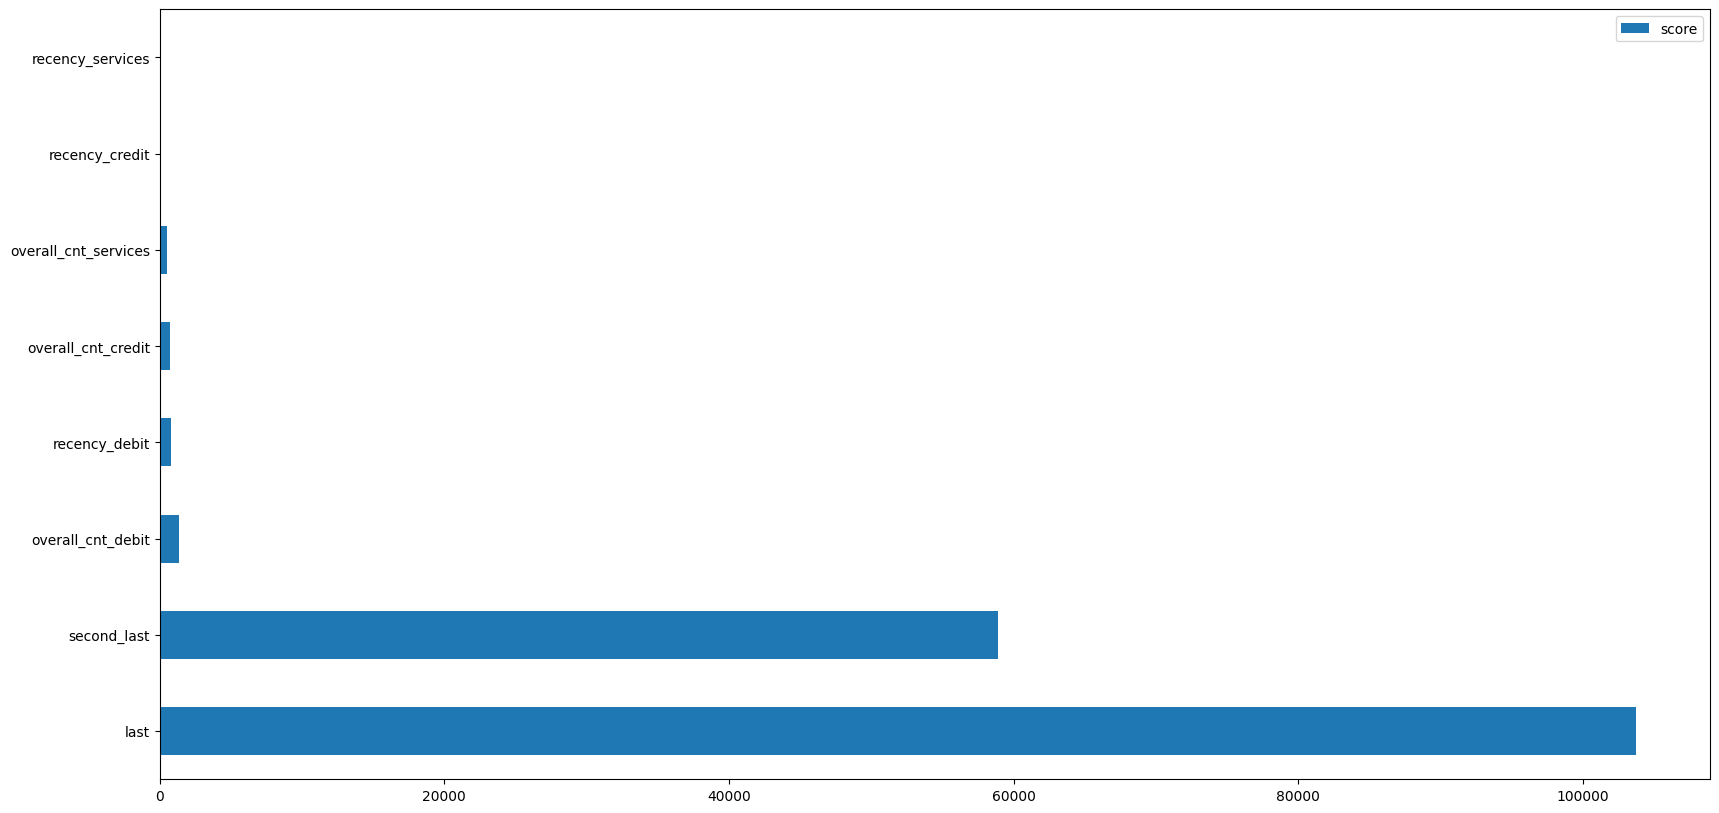

In [47]:

feature_important = model.get_booster().get_score(importance_type='gain')
keys = list(feature_important.keys())
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.nlargest(40, columns="score").plot(kind='barh', figsize = (20,10)) ## plot top 40 features

# Process for Churn Prediction using Machine Learning Models

## 1. Data Preprocessing and Feature Generation

### Data Cleaning
- Identify and remove NaN values.
- Analyze the minimum, maximum, and mean values for all features.

### Types of Features
We categorize features into three main types:

#### **Overall Facts**
These facts are based on historical data, excluding the latest 30 days:

1. `account_id`: Unique identifier of an account
2. `overall_cnt_credit`: Total transaction count in credit `txn_flow`
3. `overall_cnt_debit`: Total transaction count in debit `txn_flow`
4. `overall_cnt_services`: Total transaction count in services `txn_flow`
5. `overall_amt_credit`: Total transaction amount in credit `txn_flow`
6. `overall_amt_debit`: Total transaction amount in debit `txn_flow`
7. `overall_amt_services`: Total transaction amount in services `txn_flow`
8. `recency_credit`: Days since last credit transaction
9. `recency_debit`: Days since last debit transaction
10. `recency_services`: Days since last services transaction
11. `account_age`: Days since account creation

#### **Churn Identifying Algorithm Facts**
Derived from a churn pattern-identifying algorithm, using 60 days of data (excluding the latest 30 days):

1. `txn_cnt_3_credit`: Total transaction count (30-60 days) in credit `txn_flow`
2. `txn_cnt_3_debit`: Total transaction count (30-60 days) in debit `txn_flow`
3. `txn_cnt_3_services`: Total transaction count (30-60 days) in services `txn_flow`
4. `txn_cnt_2_credit`: Total transaction count (last 30 days) in credit `txn_flow`
5. `txn_cnt_2_debit`: Total transaction count (last 30 days) in debit `txn_flow`
6. `txn_cnt_2_services`: Total transaction count (last 30 days) in services `txn_flow`
7. `txn_amt_3_credit`: Total transaction amount (30-60 days) in credit `txn_flow`
8. `txn_amt_3_debit`: Total transaction amount (30-60 days) in debit `txn_flow`
9. `txn_amt_3_services`: Total transaction amount (30-60 days) in services `txn_flow`
10. `txn_amt_2_credit`: Total transaction amount (last 30 days) in credit `txn_flow`
11. `txn_amt_2_debit`: Total transaction amount (last 30 days) in debit `txn_flow`
12. `txn_amt_2_services`: Total transaction amount (last 30 days) in services `txn_flow`

#### **Modified `txn_flow` Facts**
Using the latest 90 days of data, transactions are categorized into different segments:

| `txn_flow_name`           | `id` | Condition |
|---------------------------|----|-----------|
| `not_present`             | 0  | `credit == 0 and debit == 0 and services == 0` |
| `credit`                  | 1  | `credit >= 1 and debit == 0 and services == 0` |
| `debit`                   | 2  | `credit == 0 and debit >= 1 and services == 0` |
| `services`                | 3  | `credit == 0 and debit == 0 and services >= 1` |
| `credit_debit`            | 4  | `credit >= 1 and debit >= 1 and services == 0` |
| `credit_services`         | 5  | `credit >= 1 and debit == 0 and services >= 1` |
| `debit_services`          | 6  | `credit == 0 and debit >= 1 and services >= 1` |
| `credit_debit_service`    | 7  | `credit >= 1 and debit >= 1 and services >= 1` |

We define transaction segments based on 30-day periods:

1. **Segment 1 (current)**: Latest 30 days
2. **Segment 2 (last)**: 31-60 days
3. **Segment 3 (second_last)**: 61-90 days
4. **`is_churn`**: `1` if `current == 0`, else `0`

After merging all facts, we obtain 26 features categorized into these three groups.

---

## 2. Feature Engineering
- We remove constant and highly correlated features using `SmartCorrelatedSelection`.
- From the initial 26 features, we select 16 key features:


---

## 3. Model Building
We train four different machine learning models and evaluate their performance using the `ROC-AUC` score.

### **a. Logistic Regression**
- Train set ROC-AUC: `0.6230`
- Test set ROC-AUC: `0.6237`

### **b. Decision Tree Classifier**
- Train set ROC-AUC: `0.8436`
- Test set ROC-AUC: `0.8438`

### **c. Random Forest Classifier**
- Train set ROC-AUC: `0.8415`
- Test set ROC-AUC: `0.8419`

### **d. XGBoost**
- Test set ROC-AUC: **`0.8458`**

### **Conclusion**
XGBoost achieved the highest ROC-AUC score (`0.8458`), making it the most effective model for churn prediction.
